In [1]:
# !pip install 'numpy>=1.16,<1.25'
!uv pip install 'pandas>=1.0.1'
!uv pip install 'torch>=1.9.0'
!uv pip install 'pymoo==0.6.0'
!uv pip install 'scikit-learn>=0.22'
!uv pip install 'gpytorch>=1.4.0'
!uv pip install 'GPy>=1.9.9'
!uv pip install 'catboost>=0.24.4'
!uv pip install disjoint-set

Audited 1 package in 201ms
Audited 1 package in 390ms
Audited 1 package in 331ms
Audited 1 package in 80ms
Audited 1 package in 79ms
Resolved 7 packages in 1.09s                                         
   Building scipy==1.12.0                                              
   Building scipy==1.12.0                                      
   Building numpy==1.26.4
   Building scipy==1.12.0                                      
   Building numpy==1.26.4
   Building gpy==1.13.2
   Building scipy==1.12.0                                      
   Building numpy==1.26.4
   Building gpy==1.13.2
   Building scipy==1.12.0                                      
   Building numpy==1.26.4
   Building gpy==1.13.2
   Building scipy==1.12.0                                      
   Building numpy==1.26.4
   Building gpy==1.13.2
   Building scipy==1.12.0                                      
   Building numpy==1.26.4
   Building gpy==1.13.2
   Building scipy==1.12.0                                      
 

In [2]:
!uv pip install HEBO --no-deps

Resolved 1 package in 350ms                                          
Audited 1 package in 0.17ms


# Example with a 2D synthetic function

Let's consider a simple example in 2-dimension so we can visualize everything.

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from hebo.optimizers.hebo import HEBO
from hebo.optimizers.bo import BO

import warnings
warnings.filterwarnings("ignore")

### Objective Function

We define below an objective function `obj` that takes as inputs a dataframe object `pandas.DataFrame`, i.e. a table, with two columns named `"x0","x1"`.

In [4]:
a = 1.0
b = 5.1 / (4 * np.pi**2)
c = 5 / np.pi
d = 6.0
e = 10.0
f = 1 / (8 * np.pi)

def branin_hoo(x : pd.DataFrame) -> np.ndarray:
    """Calculates the Branin-Hoo function value."""
    x = x[['x0','x1']].values
    x0, x1 = x[:,0], x[:,1]
    term1 = a * (x1 - b * x0**2 + c * x0 - d)**2
    term2 = e * (1 - f) * np.cos(x0)
    term3 = e
    return np.array(term1 + term2 + term3).reshape(-1, 1)

### Design  Space

To be able to use `HEBO` and in general for using any numerical optimizer, we need to specify the design space, i.e. the space in which the inputs to the objective live in and a bounding box in which we will search for the optimal input $x^*=\arg\min f(x)$ that minimizes the objective $f(\cdot)$.

In [5]:
from hebo.design_space.design_space import DesignSpace
space = DesignSpace().parse([
    {'name' : 'x0', 'type' : 'num', 'lb' : -5, 'ub' : 10},
    {'name' : 'x1', 'type' : 'num', 'lb' : 0,  'ub' : 15}
])

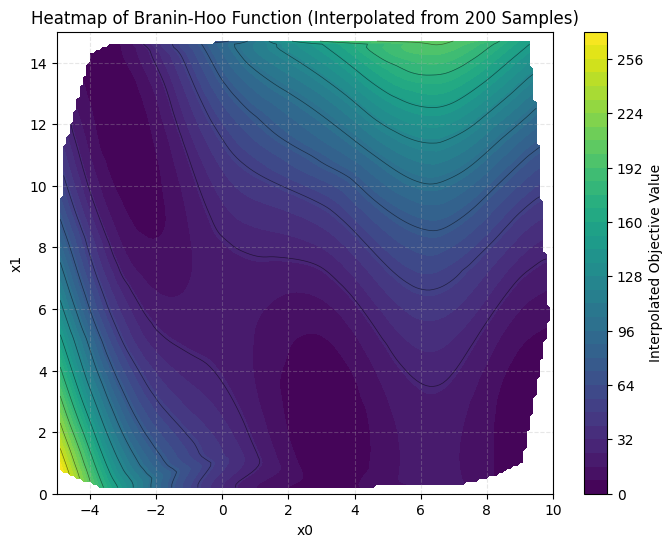

In [6]:
from scipy.interpolate import griddata

# 1. Generate Scattered Data Points
X_df = space.sample(200)
Y_flat = branin_hoo(X_df).ravel()

points = X_df[['x0', 'x1']].values
values = Y_flat

# --- 2. Define the Target Grid for Interpolation ---
n_points = 150  # Define resolution for the heatmap (150x150 grid)
x0_arr = np.linspace(space.opt_lb[0], space.opt_ub[0], n_points)
x1_arr = np.linspace(space.opt_lb[1], space.opt_ub[1], n_points)
X0_grid, X1_grid = np.meshgrid(x0_arr, x1_arr)

# --- 3. Interpolate the Scattered Data onto the Grid ---
Z_grid = griddata(points, values, (X0_grid, X1_grid), method='cubic')

# --- 4. Create the Heatmap/Contour Plot ---
plt.figure(figsize=(8, 6))
cont = plt.contourf(X0_grid, X1_grid, Z_grid, levels=40, cmap='viridis')
plt.contour(X0_grid, X1_grid, Z_grid, levels=10, colors='k', linestyles='-', linewidths=0.5, alpha=0.5)
plt.colorbar(cont, label="Interpolated Objective Value")
plt.xlabel("x0")
plt.ylabel("x1")
plt.title("Heatmap of Branin-Hoo Function (Interpolated from 200 Samples)")
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

### BO Loop

We compare three BO algorithms:
- The basic BO with LCB acquisition
- HEBO where three acquisition functions are ensembled, with input warping and power transformation
- HEBO with parallel recommendation.

We'll run BO with LCB firstly, we can see the interface is very simple

In [7]:
NUM_ITERATIONS = 64

In [8]:
bo = BO(space)
for i in range(NUM_ITERATIONS):
    rec_x = bo.suggest(n_suggestions=1)
    bo.observe(rec_x, branin_hoo(rec_x))
    if i % 4 == 0:
        print('Iter %d, best_y = %.2f' % (i, bo.y.min()))

Iter 0, best_y = 14.71

Compiled modules for significant speedup can not be used!
https://pymoo.org/installation.html#installation

To disable this warning:
from pymoo.config import Config
Config.warnings['not_compiled'] = False

Iter 4, best_y = 6.94
Iter 8, best_y = 0.59
Iter 12, best_y = 0.59
Iter 16, best_y = 0.59
Iter 20, best_y = 0.59
Iter 24, best_y = 0.50
Iter 28, best_y = 0.40
Iter 32, best_y = 0.40
Iter 36, best_y = 0.40
Iter 40, best_y = 0.40
Iter 44, best_y = 0.40
Iter 48, best_y = 0.40
Iter 52, best_y = 0.40
Iter 56, best_y = 0.40
Iter 60, best_y = 0.40


We then run the sequential HEBO

In [9]:
hebo_seq   = HEBO(space, model_name = 'gp', rand_sample = 4)
for i in range(NUM_ITERATIONS):
    rec_x = hebo_seq.suggest(n_suggestions=1)
    hebo_seq.observe(rec_x, branin_hoo(rec_x))
    if i % 4 == 0:
        print('Iter %d, best_y = %.2f' % (i, hebo_seq.y.min()))

Iter 0, best_y = 132.75
Iter 4, best_y = 13.61
Iter 8, best_y = 12.22
Iter 12, best_y = 1.07
Iter 16, best_y = 0.68
Iter 20, best_y = 0.42
Iter 24, best_y = 0.41
Iter 28, best_y = 0.40
Iter 32, best_y = 0.40
Iter 36, best_y = 0.40
Iter 40, best_y = 0.40
Iter 44, best_y = 0.40
Iter 48, best_y = 0.40
Iter 52, best_y = 0.40
Iter 56, best_y = 0.40
Iter 60, best_y = 0.40


Finally, we run the parallel HEBO, as it would do parallel recommendation, we only run it for 16 iterations

In [10]:
hebo_batch = HEBO(space, model_name = 'gp', rand_sample = 4)
for i in range(NUM_ITERATIONS // 8):
    rec_x = hebo_batch.suggest(n_suggestions=8)
    hebo_batch.observe(rec_x, branin_hoo(rec_x))
    print('Iter %d, best_y = %.2f' % (i, hebo_batch.y.min()))

Iter 0, best_y = 0.55
Iter 1, best_y = 0.55
Iter 2, best_y = 0.55
Iter 3, best_y = 0.42
Iter 4, best_y = 0.40
Iter 5, best_y = 0.40
Iter 6, best_y = 0.40
Iter 7, best_y = 0.40


We plot the converge below, we can see it seems that the LCB converges slightly faster than HEBO, while batched HEBO used most function evaluations.

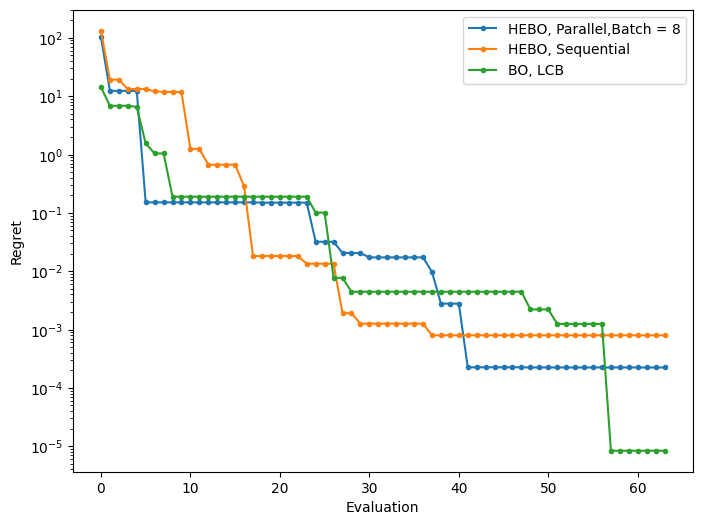

In [11]:
conv_hebo_batch = np.minimum.accumulate(hebo_batch.y)
conv_hebo_seq = np.minimum.accumulate(hebo_seq.y)
conv_bo_seq = np.minimum.accumulate(bo.y)

plt.figure(figsize = (8,6))
plt.semilogy(conv_hebo_batch - 0.3978922, '.-', label = 'HEBO, Parallel,Batch = 8')
plt.semilogy(conv_hebo_seq - 0.3978922, '.-', label = 'HEBO, Sequential')
plt.semilogy(conv_bo_seq - 0.3978922, '.-', label = 'BO, LCB')

plt.xlabel('Evaluation')
plt.ylabel('Regret')
plt.legend()

Batched HEBO used most function evaluations because it recommend eight points per iterations, we can also plot the converge against **iterations** instead of **evaluations**.

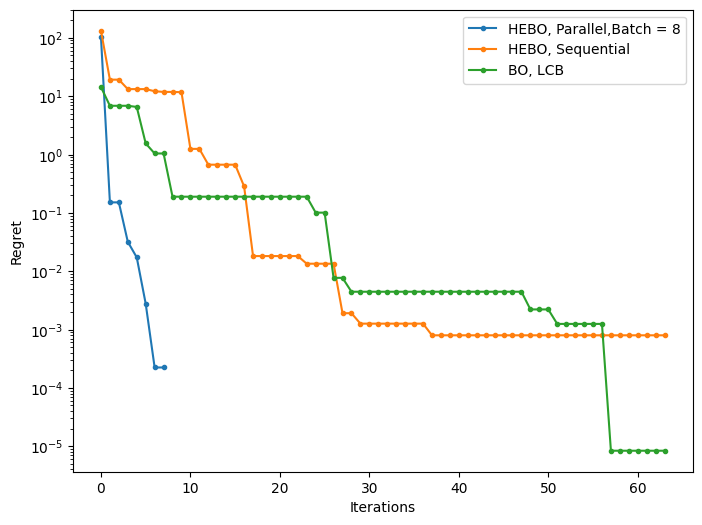

In [12]:
plt.figure(figsize = (8,6))
plt.semilogy(conv_hebo_batch[::8] - 0.3978922, '.-', label = 'HEBO, Parallel,Batch = 8')
plt.semilogy(conv_hebo_seq - 0.3978922, '.-', label = 'HEBO, Sequential')
plt.semilogy(conv_bo_seq - 0.3978922, '.-', label = 'BO, LCB')

plt.xlabel('Iterations')
plt.ylabel('Regret')
plt.legend()

# Example on a real dataset

For that part, load the `BH_dataset.csv` dataset from your laptop to the notebook.

Now, because HEBO is by default *minimizing* functions, we just need to take the negative of the `Target` column as objective values if we want to maximize the target.

So we flip the target values to be `max(targets) - targets` so that they are all nonegative and finding the smallest one is equivalent to finding the largest original target value.

In [45]:
data = pd.read_csv('dataset/BH_dataset.csv')
true_best_y = data["yield"].max()
data["yield"] = data["yield"].max() - data["yield"]

In [46]:
params = [
    {'name' : 'AcidRed871_0gL',     'type' : 'num', 'lb' : 0, 'ub' : 5},
    {'name' : 'L-Cysteine-50gL',    'type' : 'num', 'lb' : 0, 'ub' : 5},
    {'name' : 'MethyleneB_250mgL',  'type' : 'num', 'lb' : 0, 'ub' : 5},
    {'name' : 'NaCl-3M',            'type' : 'num', 'lb' : 0, 'ub' : 5},
    {'name' : 'NaOH-1M',            'type' : 'num', 'lb' : 0, 'ub' : 5},
    {'name' : 'P10-MIX1',           'type' : 'num', 'lb' : 0, 'ub' : 5},
    {'name' : 'PVP-1wt',            'type' : 'num', 'lb' : 0, 'ub' : 5},
    {'name' : 'RhodamineB1_0gL',    'type' : 'num', 'lb' : 0, 'ub' : 5},
    {'name' : 'SDS-1wt',            'type' : 'num', 'lb' : 0, 'ub' : 5},
    {'name' : 'Sodiumsilicate-1wt', 'type' : 'num', 'lb' : 0, 'ub' : 5},
]

params_columns = data.columns.tolist()
for p in ['yield', 'cost', 'new_index']:
    params_columns.remove(p)

space = DesignSpace().parse([
    {'name' : p, 'type' : 'num', 'lb' : data[p].min(), 'ub' : data[p].max()} for p in params_columns
])

In [47]:
NUM_ITERATIONS = 200
NUM_SUGGESTIONS_PER_ITERATION = 1

### Optimization with a dynamic Oracle

Because in this case we do not have a real objective function definition, i.e. an *oracle*, we are going to use the dataset directly to show how BO works. We randomly split the data into an observation set and a test set, making sure the best point is in the test set.

In particular, we make sure that the best 10% points are not in the training set.

In [48]:
from sklearn.model_selection import train_test_split

num_best_to_exclude = max(1, int(0.10 * len(data)))
data_best = data.sort_values(by='yield').head(num_best_to_exclude)
indices_to_drop = data_best.index

data_rest = data.drop(indices_to_drop)
data_train, data_test_partial = train_test_split(data_rest, test_size=0.9, random_state=42)
data_test = pd.concat([data_test_partial, data_best])

X_train = data_train[space.numeric_names]
Y_train = data_train["yield"].values.reshape(-1, 1)
X_test = data_test[space.numeric_names]
Y_test = data_test["yield"].values.reshape(-1, 1)

print("#Train data", data_train.shape[0])
print("#Test data", data_test.shape[0])

#Train data 155
#Test data 1573


We define a function to find the closest point to the `HEBO` suggestion in the `X_test` dataframe and we take the corresponding value from `Y_test` as objective value.

In [49]:
from scipy.spatial.distance import cdist # Required for efficient distance calculation

def find_nearest_row(df: pd.DataFrame, vector: np.ndarray, feature_cols: list = None) -> int:
    """
    Finds the row in the DataFrame that is closest to the input vector
    using Euclidean distance.
    """
    if not feature_cols:
        feature_cols = df.columns.tolist()

    # 1. Extract feature data from the DataFrame
    df_features = df[feature_cols].values

    # 2. Calculate the distance between the vector and all rows
    # cdist is highly efficient for this calculation
    distances = cdist(df_features, vector.reshape(1, -1), metric='euclidean')

    # 3. Find the index of the minimum distance
    nearest_idx_in_df = np.argmin(distances)

    # 4. Return the full row from the original DataFrame
    return nearest_idx_in_df

In [59]:
hebo = HEBO(space, model_name='gp')
hebo.observe(X_train, Y_train) # observe X_train and Y_train
for i in range(NUM_ITERATIONS):
    rec_x = hebo.suggest(n_suggestions=NUM_SUGGESTIONS_PER_ITERATION) # HEBO suggests a new point
    idx = find_nearest_row(X_test, rec_x.values) # find closest point for which we have the true value in X_test
    rec_y = Y_test[idx]
    hebo.observe(rec_x, rec_y)
    if i % 4 == 0:
        print(f'Iter {i}, best_y = {hebo.y.min():.5f}, y_opt = {Y_test.min():.5f} '
              f'(true best_y = {-(hebo.y.min()-true_best_y):.5f}, true y_opt = {true_best_y:.5f})')

Iter 0, best_y = 30.74000, y_opt = 0.00000 (true best_y = 69.26000, true y_opt = 100.00000)
Iter 4, best_y = 13.57000, y_opt = 0.00000 (true best_y = 86.43000, true y_opt = 100.00000)
Iter 8, best_y = 13.57000, y_opt = 0.00000 (true best_y = 86.43000, true y_opt = 100.00000)
Iter 12, best_y = 13.57000, y_opt = 0.00000 (true best_y = 86.43000, true y_opt = 100.00000)
Iter 16, best_y = 13.57000, y_opt = 0.00000 (true best_y = 86.43000, true y_opt = 100.00000)
Iter 20, best_y = 13.57000, y_opt = 0.00000 (true best_y = 86.43000, true y_opt = 100.00000)
Iter 24, best_y = 13.57000, y_opt = 0.00000 (true best_y = 86.43000, true y_opt = 100.00000)
Iter 28, best_y = 13.57000, y_opt = 0.00000 (true best_y = 86.43000, true y_opt = 100.00000)
Iter 32, best_y = 13.57000, y_opt = 0.00000 (true best_y = 86.43000, true y_opt = 100.00000)
Iter 36, best_y = 13.57000, y_opt = 0.00000 (true best_y = 86.43000, true y_opt = 100.00000)
Iter 40, best_y = 13.57000, y_opt = 0.00000 (true best_y = 86.43000, true

In [60]:
bo = BO(space, model_name='gp')
bo.observe(X_train, Y_train) # observe X_train and Y_train
for i in range(NUM_ITERATIONS):
    rec_x = bo.suggest(n_suggestions=NUM_SUGGESTIONS_PER_ITERATION) # BO suggests a new point
    idx = find_nearest_row(X_test, rec_x.values) # find closest point for which we have the true value in X_test
    rec_y = Y_test[idx]
    bo.observe(rec_x, rec_y.reshape(-1, 1))
    if i % 4 == 0:
        print(f'Iter {i}, best_y = {bo.y.min():.5f}, y_opt = {Y_test.min():.5f} '
              f'(true best_y = {-(bo.y.min()-true_best_y):.5f}, true y_opt = {true_best_y:.5f})')

Iter 0, best_y = 43.55000, y_opt = 0.00000 (true best_y = 56.45000, true y_opt = 100.00000)
Iter 4, best_y = 43.55000, y_opt = 0.00000 (true best_y = 56.45000, true y_opt = 100.00000)
Iter 8, best_y = 43.55000, y_opt = 0.00000 (true best_y = 56.45000, true y_opt = 100.00000)
Iter 12, best_y = 43.55000, y_opt = 0.00000 (true best_y = 56.45000, true y_opt = 100.00000)
Iter 16, best_y = 43.55000, y_opt = 0.00000 (true best_y = 56.45000, true y_opt = 100.00000)
Iter 20, best_y = 43.55000, y_opt = 0.00000 (true best_y = 56.45000, true y_opt = 100.00000)
Iter 24, best_y = 43.55000, y_opt = 0.00000 (true best_y = 56.45000, true y_opt = 100.00000)
Iter 28, best_y = 43.55000, y_opt = 0.00000 (true best_y = 56.45000, true y_opt = 100.00000)
Iter 32, best_y = 43.55000, y_opt = 0.00000 (true best_y = 56.45000, true y_opt = 100.00000)
Iter 36, best_y = 32.96000, y_opt = 0.00000 (true best_y = 67.04000, true y_opt = 100.00000)
Iter 40, best_y = 32.96000, y_opt = 0.00000 (true best_y = 67.04000, true

In [61]:
rs_log = Y_train.flatten()
for i in range(NUM_ITERATIONS):
    rec_x = space.sample(NUM_SUGGESTIONS_PER_ITERATION) # sample a new point from the search space
    idx = find_nearest_row(X_test, rec_x.values) # find closest point for which we have the true value in X_test
    rec_y = Y_test[idx]
    rs_log = np.concatenate([rs_log, rec_y])
    if i % 4 == 0:
        print(f'Iter {i}, best_y = {rs_log.min():.5f}, y_opt = {Y_test.min():.5f} '
              f'(true best_y = {-(rs_log.min()-true_best_y):.5f}, true y_opt = {true_best_y:.5f})')

Iter 0, best_y = 43.55000, y_opt = 0.00000 (true best_y = 56.45000, true y_opt = 100.00000)
Iter 4, best_y = 43.55000, y_opt = 0.00000 (true best_y = 56.45000, true y_opt = 100.00000)
Iter 8, best_y = 26.07000, y_opt = 0.00000 (true best_y = 73.93000, true y_opt = 100.00000)
Iter 12, best_y = 26.07000, y_opt = 0.00000 (true best_y = 73.93000, true y_opt = 100.00000)
Iter 16, best_y = 21.56000, y_opt = 0.00000 (true best_y = 78.44000, true y_opt = 100.00000)
Iter 20, best_y = 21.56000, y_opt = 0.00000 (true best_y = 78.44000, true y_opt = 100.00000)
Iter 24, best_y = 21.56000, y_opt = 0.00000 (true best_y = 78.44000, true y_opt = 100.00000)
Iter 28, best_y = 21.56000, y_opt = 0.00000 (true best_y = 78.44000, true y_opt = 100.00000)
Iter 32, best_y = 21.56000, y_opt = 0.00000 (true best_y = 78.44000, true y_opt = 100.00000)
Iter 36, best_y = 21.56000, y_opt = 0.00000 (true best_y = 78.44000, true y_opt = 100.00000)
Iter 40, best_y = 21.56000, y_opt = 0.00000 (true best_y = 78.44000, true

Note that we plot the *Regret* i.e. how close we are getting to the best value in the test set.

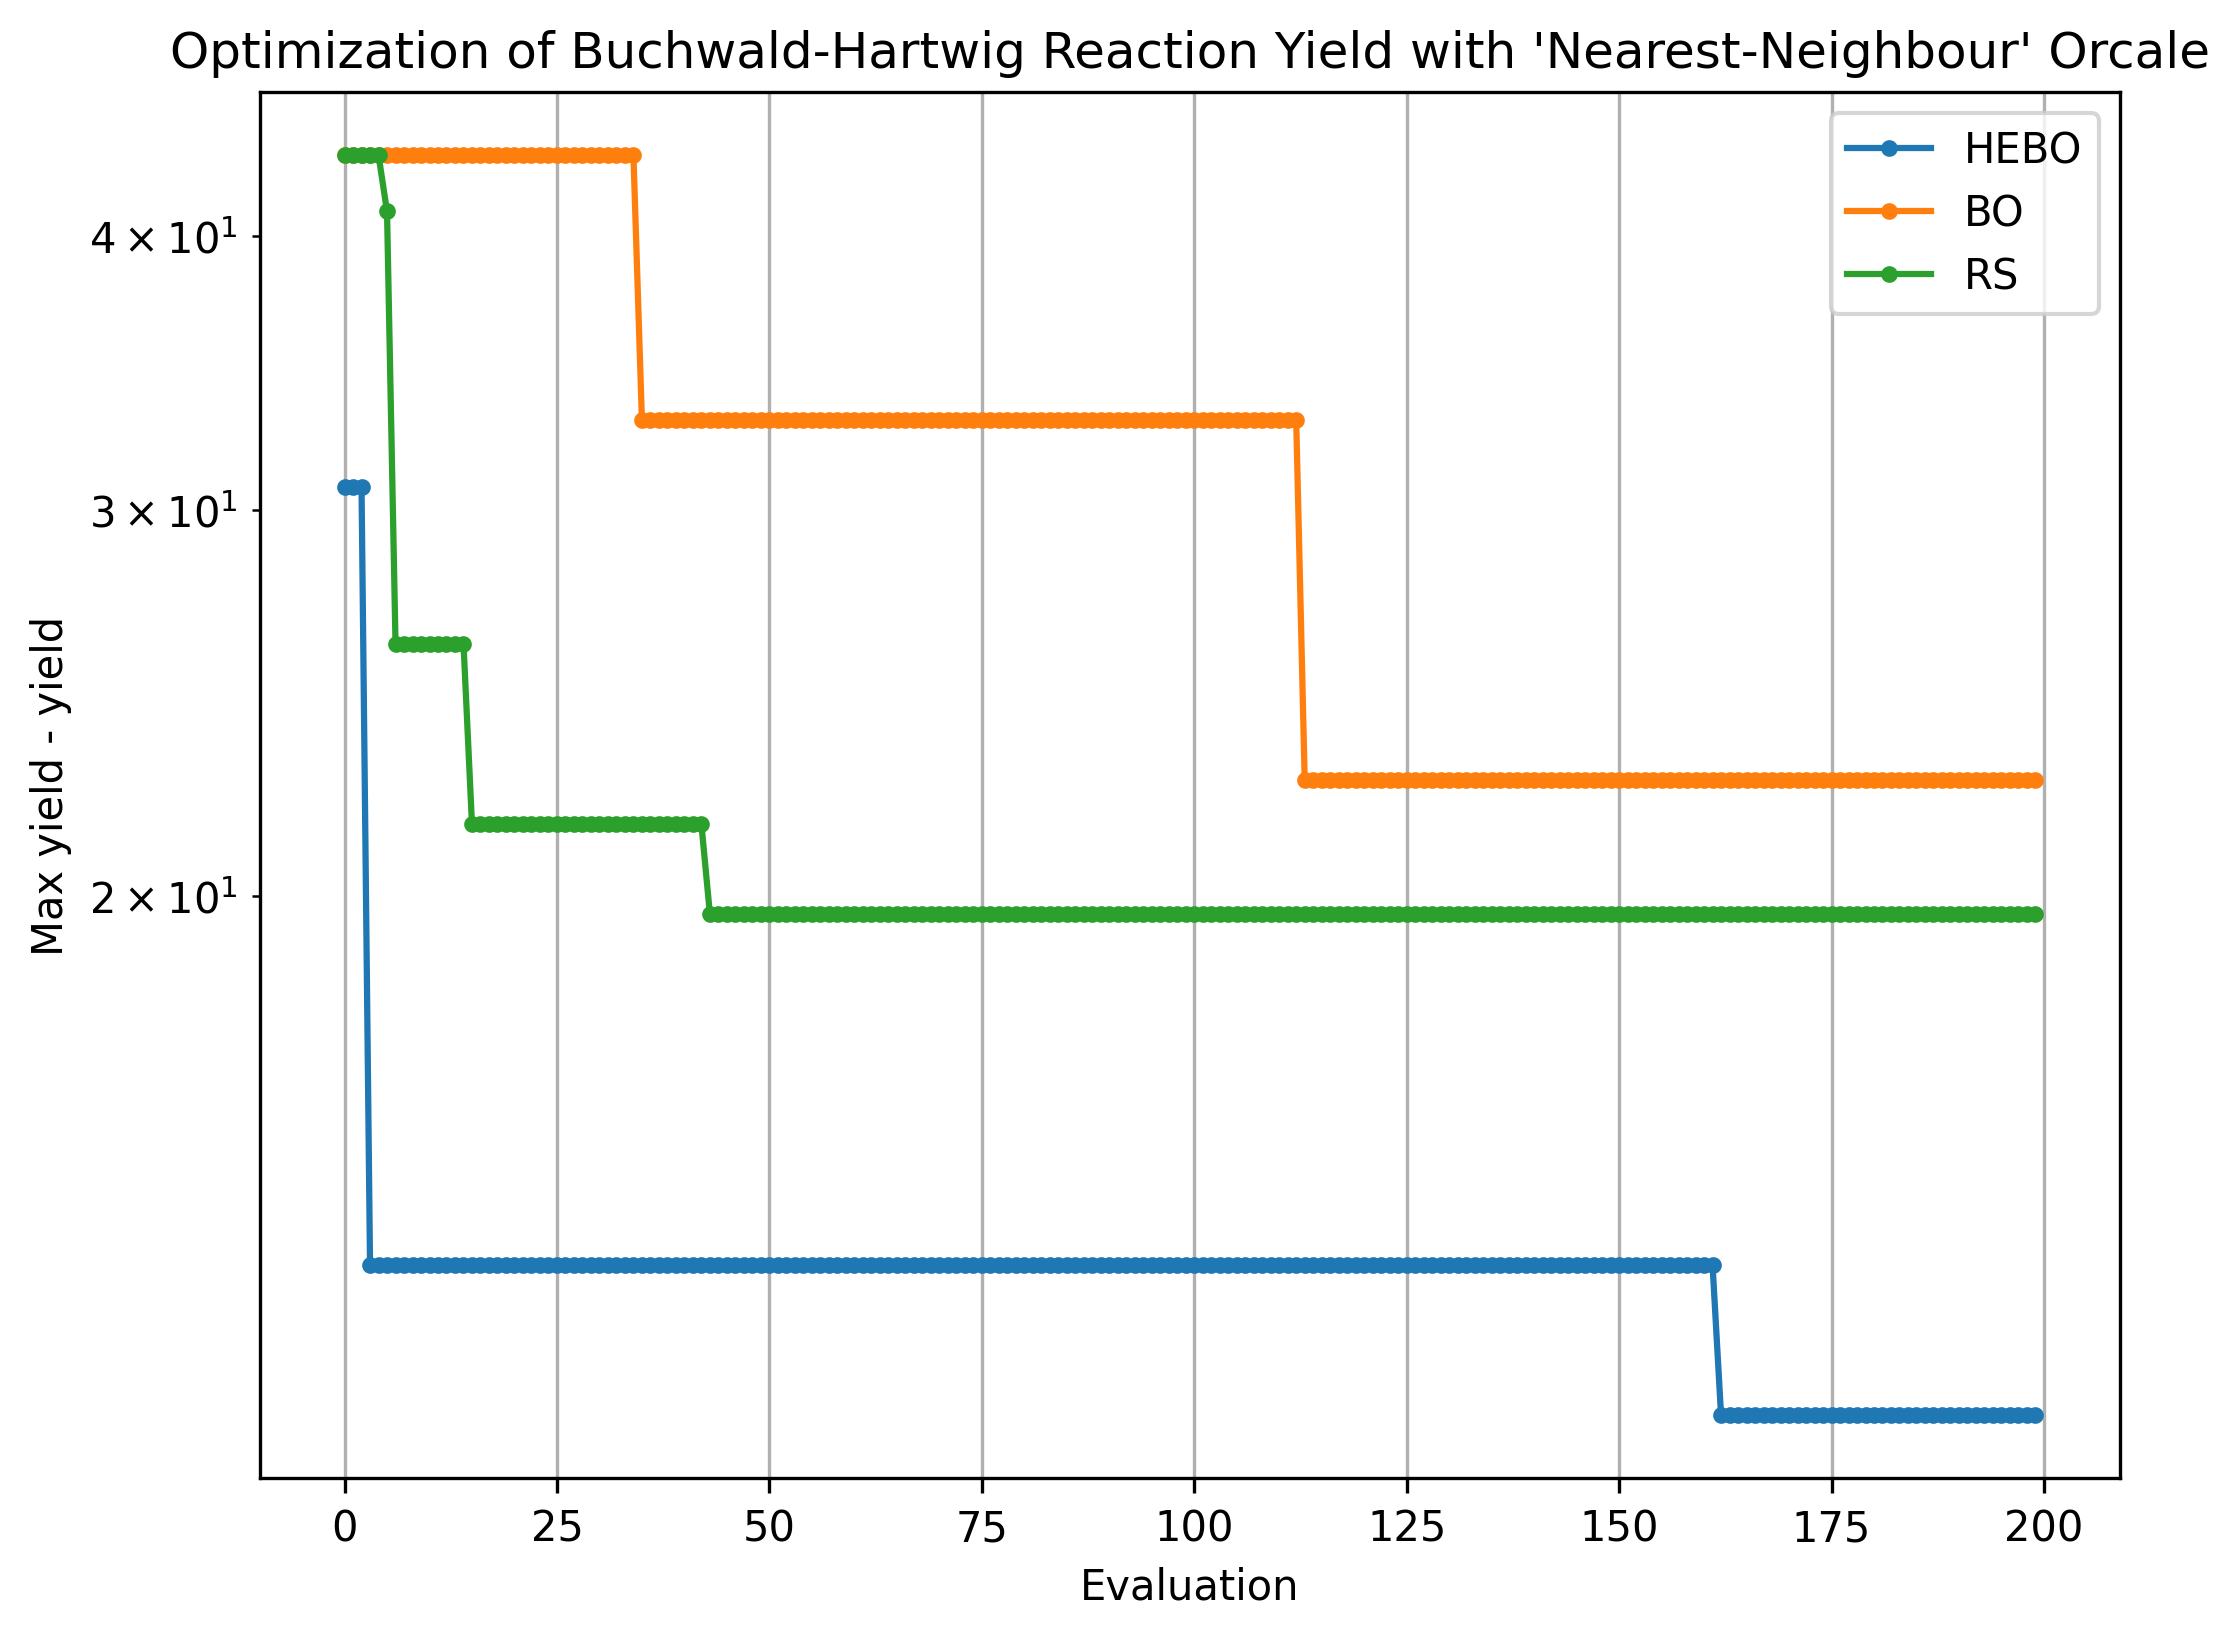

In [62]:
conv_hebo = np.minimum.accumulate(hebo.y)
conv_bo = np.minimum.accumulate(bo.y)
conv_rs = np.minimum.accumulate(rs_log)

plt.figure(figsize = (8,6), dpi=300)
plt.semilogy(conv_hebo[len(X_train):], '.-', label = 'HEBO')
plt.semilogy(conv_bo[len(X_train):], '.-', label = 'BO')
plt.semilogy(conv_rs[len(X_train):], '.-', label = 'RS')
plt.xlabel('Evaluation')
plt.ylabel('Max yield - yield')
plt.legend()
plt.grid()
plt.title("Optimization of Buchwald-Hartwig Reaction Yield with 'Nearest-Neighbour' Orcale")
plt.show()

### Optimization with a learnt Orcale

In this example, we are going to *learn* an oracle function.

In the previous example we were finding the point in the test dataset closest to the new suggested point by the BO algoritm and using its real `Target` value. This has the benefit of using the *true* value associated with the ppoint, but the drawback is that we are not really observing the point that the BO algorithm suggested.

In this following example we make the opposite tradeoff: we learn an oracle, i.e. we learn a model of the `Target` values with a regression model, and we use this *learnt oracle* as our optimization objective. The advantage of this method is that we can now use this oracle to evaluate any point suggested by the BO algorithm. The drawback is that the values are not the *true* values but only *predicted*.

Both examples are methods that are used in practice, the user needs to be aware fo the drawbacks and advantages of both methods but they are both valid ways of comparing optimization algorithms. In the ideal case of course we would like to evaluate the true `Target` value of each new suggested point, but in practice this is not possible because of the prohibitive costs of such evaluations (e.g. requiring wet lab experiments).

In [63]:
from typing import Callable

def construct_oracle(
    data_path: str,
    impl: str = "random_forest"
) -> Callable[[pd.DataFrame], np.ndarray]:

    data = pd.read_csv(data_path)
    data.drop(columns=["cost", "new_index"], inplace=True, errors='ignore')
    target = data["yield"]
    features = data.drop(columns=["yield"])

    # learn a decision tree model as oracle
    if impl == "random_forest":
        from sklearn.ensemble import RandomForestRegressor
        model = RandomForestRegressor(n_estimators=100)
        model.fit(features, target)

        return lambda x: model.predict(x)
    else:
        raise ValueError(f"Unsupported implementation: {impl}")

In [65]:
oracle = construct_oracle(data_path="dataset/BH_dataset.csv")

In [72]:
hebo = HEBO(space, model_name='gp')
hebo.observe(X_train, Y_train) # observe X_train and Y_train
for i in range(NUM_ITERATIONS):
    rec_x = hebo.suggest(n_suggestions=NUM_SUGGESTIONS_PER_ITERATION) # HEBO suggests a new point
    rec_y = oracle(rec_x)
    hebo.observe(rec_x, rec_y)
    if i % 4 == 0:
        print(f'Iter {i}, best_y = {hebo.y.min():.5f}, y_opt = {Y_test.min():.5f} '
              f'(true best_y = {-(hebo.y.min()-true_best_y):.5f}, true y_opt = {true_best_y:.5f})')

Iter 0, best_y = 25.34180, y_opt = 0.00000 (true best_y = 74.65820, true y_opt = 100.00000)
Iter 4, best_y = 11.77490, y_opt = 0.00000 (true best_y = 88.22510, true y_opt = 100.00000)
Iter 8, best_y = 11.77490, y_opt = 0.00000 (true best_y = 88.22510, true y_opt = 100.00000)
Iter 12, best_y = 11.77490, y_opt = 0.00000 (true best_y = 88.22510, true y_opt = 100.00000)
Iter 16, best_y = 11.77490, y_opt = 0.00000 (true best_y = 88.22510, true y_opt = 100.00000)
Iter 20, best_y = 11.77490, y_opt = 0.00000 (true best_y = 88.22510, true y_opt = 100.00000)
Iter 24, best_y = 8.06230, y_opt = 0.00000 (true best_y = 91.93770, true y_opt = 100.00000)
Iter 28, best_y = 8.06230, y_opt = 0.00000 (true best_y = 91.93770, true y_opt = 100.00000)
Iter 32, best_y = 8.06230, y_opt = 0.00000 (true best_y = 91.93770, true y_opt = 100.00000)
Iter 36, best_y = 8.06230, y_opt = 0.00000 (true best_y = 91.93770, true y_opt = 100.00000)
Iter 40, best_y = 8.06230, y_opt = 0.00000 (true best_y = 91.93770, true y_op

In [75]:
bo = BO(space, model_name='gp')
bo.observe(X_train, Y_train) # observe X_train and Y_train
for i in range(NUM_ITERATIONS):
    rec_x = bo.suggest(n_suggestions=NUM_SUGGESTIONS_PER_ITERATION) # BO suggests a new point
    rec_y = oracle(rec_x)
    bo.observe(rec_x, rec_y.reshape(-1, 1))
    if i % 4 == 0:
        print(f'Iter {i}, best_y = {bo.y.min():.5f}, y_opt = {Y_test.min():.5f} '
              f'(true best_y = {-(bo.y.min()-true_best_y):.5f}, true y_opt = {true_best_y:.5f})')

Iter 0, best_y = 15.98040, y_opt = 0.00000 (true best_y = 84.01960, true y_opt = 100.00000)
Iter 4, best_y = 15.98040, y_opt = 0.00000 (true best_y = 84.01960, true y_opt = 100.00000)
Iter 8, best_y = 8.86500, y_opt = 0.00000 (true best_y = 91.13500, true y_opt = 100.00000)
Iter 12, best_y = 8.86500, y_opt = 0.00000 (true best_y = 91.13500, true y_opt = 100.00000)
Iter 16, best_y = 8.86500, y_opt = 0.00000 (true best_y = 91.13500, true y_opt = 100.00000)
Iter 20, best_y = 8.86500, y_opt = 0.00000 (true best_y = 91.13500, true y_opt = 100.00000)
Iter 24, best_y = 8.86500, y_opt = 0.00000 (true best_y = 91.13500, true y_opt = 100.00000)
Iter 28, best_y = 8.86500, y_opt = 0.00000 (true best_y = 91.13500, true y_opt = 100.00000)
Iter 32, best_y = 8.86500, y_opt = 0.00000 (true best_y = 91.13500, true y_opt = 100.00000)
Iter 36, best_y = 8.86500, y_opt = 0.00000 (true best_y = 91.13500, true y_opt = 100.00000)
Iter 40, best_y = 8.86500, y_opt = 0.00000 (true best_y = 91.13500, true y_opt = 

In [76]:
rs_log = Y_train.flatten()
for i in range(NUM_ITERATIONS):
    rec_x = space.sample(NUM_SUGGESTIONS_PER_ITERATION) # sample a new point from the search space
    rec_y = oracle(rec_x)
    rs_log = np.concatenate([rs_log, rec_y])
    if i % 4 == 0:
        print(f'Iter {i}, best_y = {rs_log.min():.5f}, y_opt = {Y_test.min():.5f} '
              f'(true best_y = {-(rs_log.min()-true_best_y):.5f}, true y_opt = {true_best_y:.5f})')

Iter 0, best_y = 20.08580, y_opt = 0.00000 (true best_y = 79.91420, true y_opt = 100.00000)
Iter 4, best_y = 17.04460, y_opt = 0.00000 (true best_y = 82.95540, true y_opt = 100.00000)
Iter 8, best_y = 17.04460, y_opt = 0.00000 (true best_y = 82.95540, true y_opt = 100.00000)
Iter 12, best_y = 11.68180, y_opt = 0.00000 (true best_y = 88.31820, true y_opt = 100.00000)
Iter 16, best_y = 11.68180, y_opt = 0.00000 (true best_y = 88.31820, true y_opt = 100.00000)
Iter 20, best_y = 11.68180, y_opt = 0.00000 (true best_y = 88.31820, true y_opt = 100.00000)
Iter 24, best_y = 8.22320, y_opt = 0.00000 (true best_y = 91.77680, true y_opt = 100.00000)
Iter 28, best_y = 8.22320, y_opt = 0.00000 (true best_y = 91.77680, true y_opt = 100.00000)
Iter 32, best_y = 8.22320, y_opt = 0.00000 (true best_y = 91.77680, true y_opt = 100.00000)
Iter 36, best_y = 8.22320, y_opt = 0.00000 (true best_y = 91.77680, true y_opt = 100.00000)
Iter 40, best_y = 8.22320, y_opt = 0.00000 (true best_y = 91.77680, true y_op

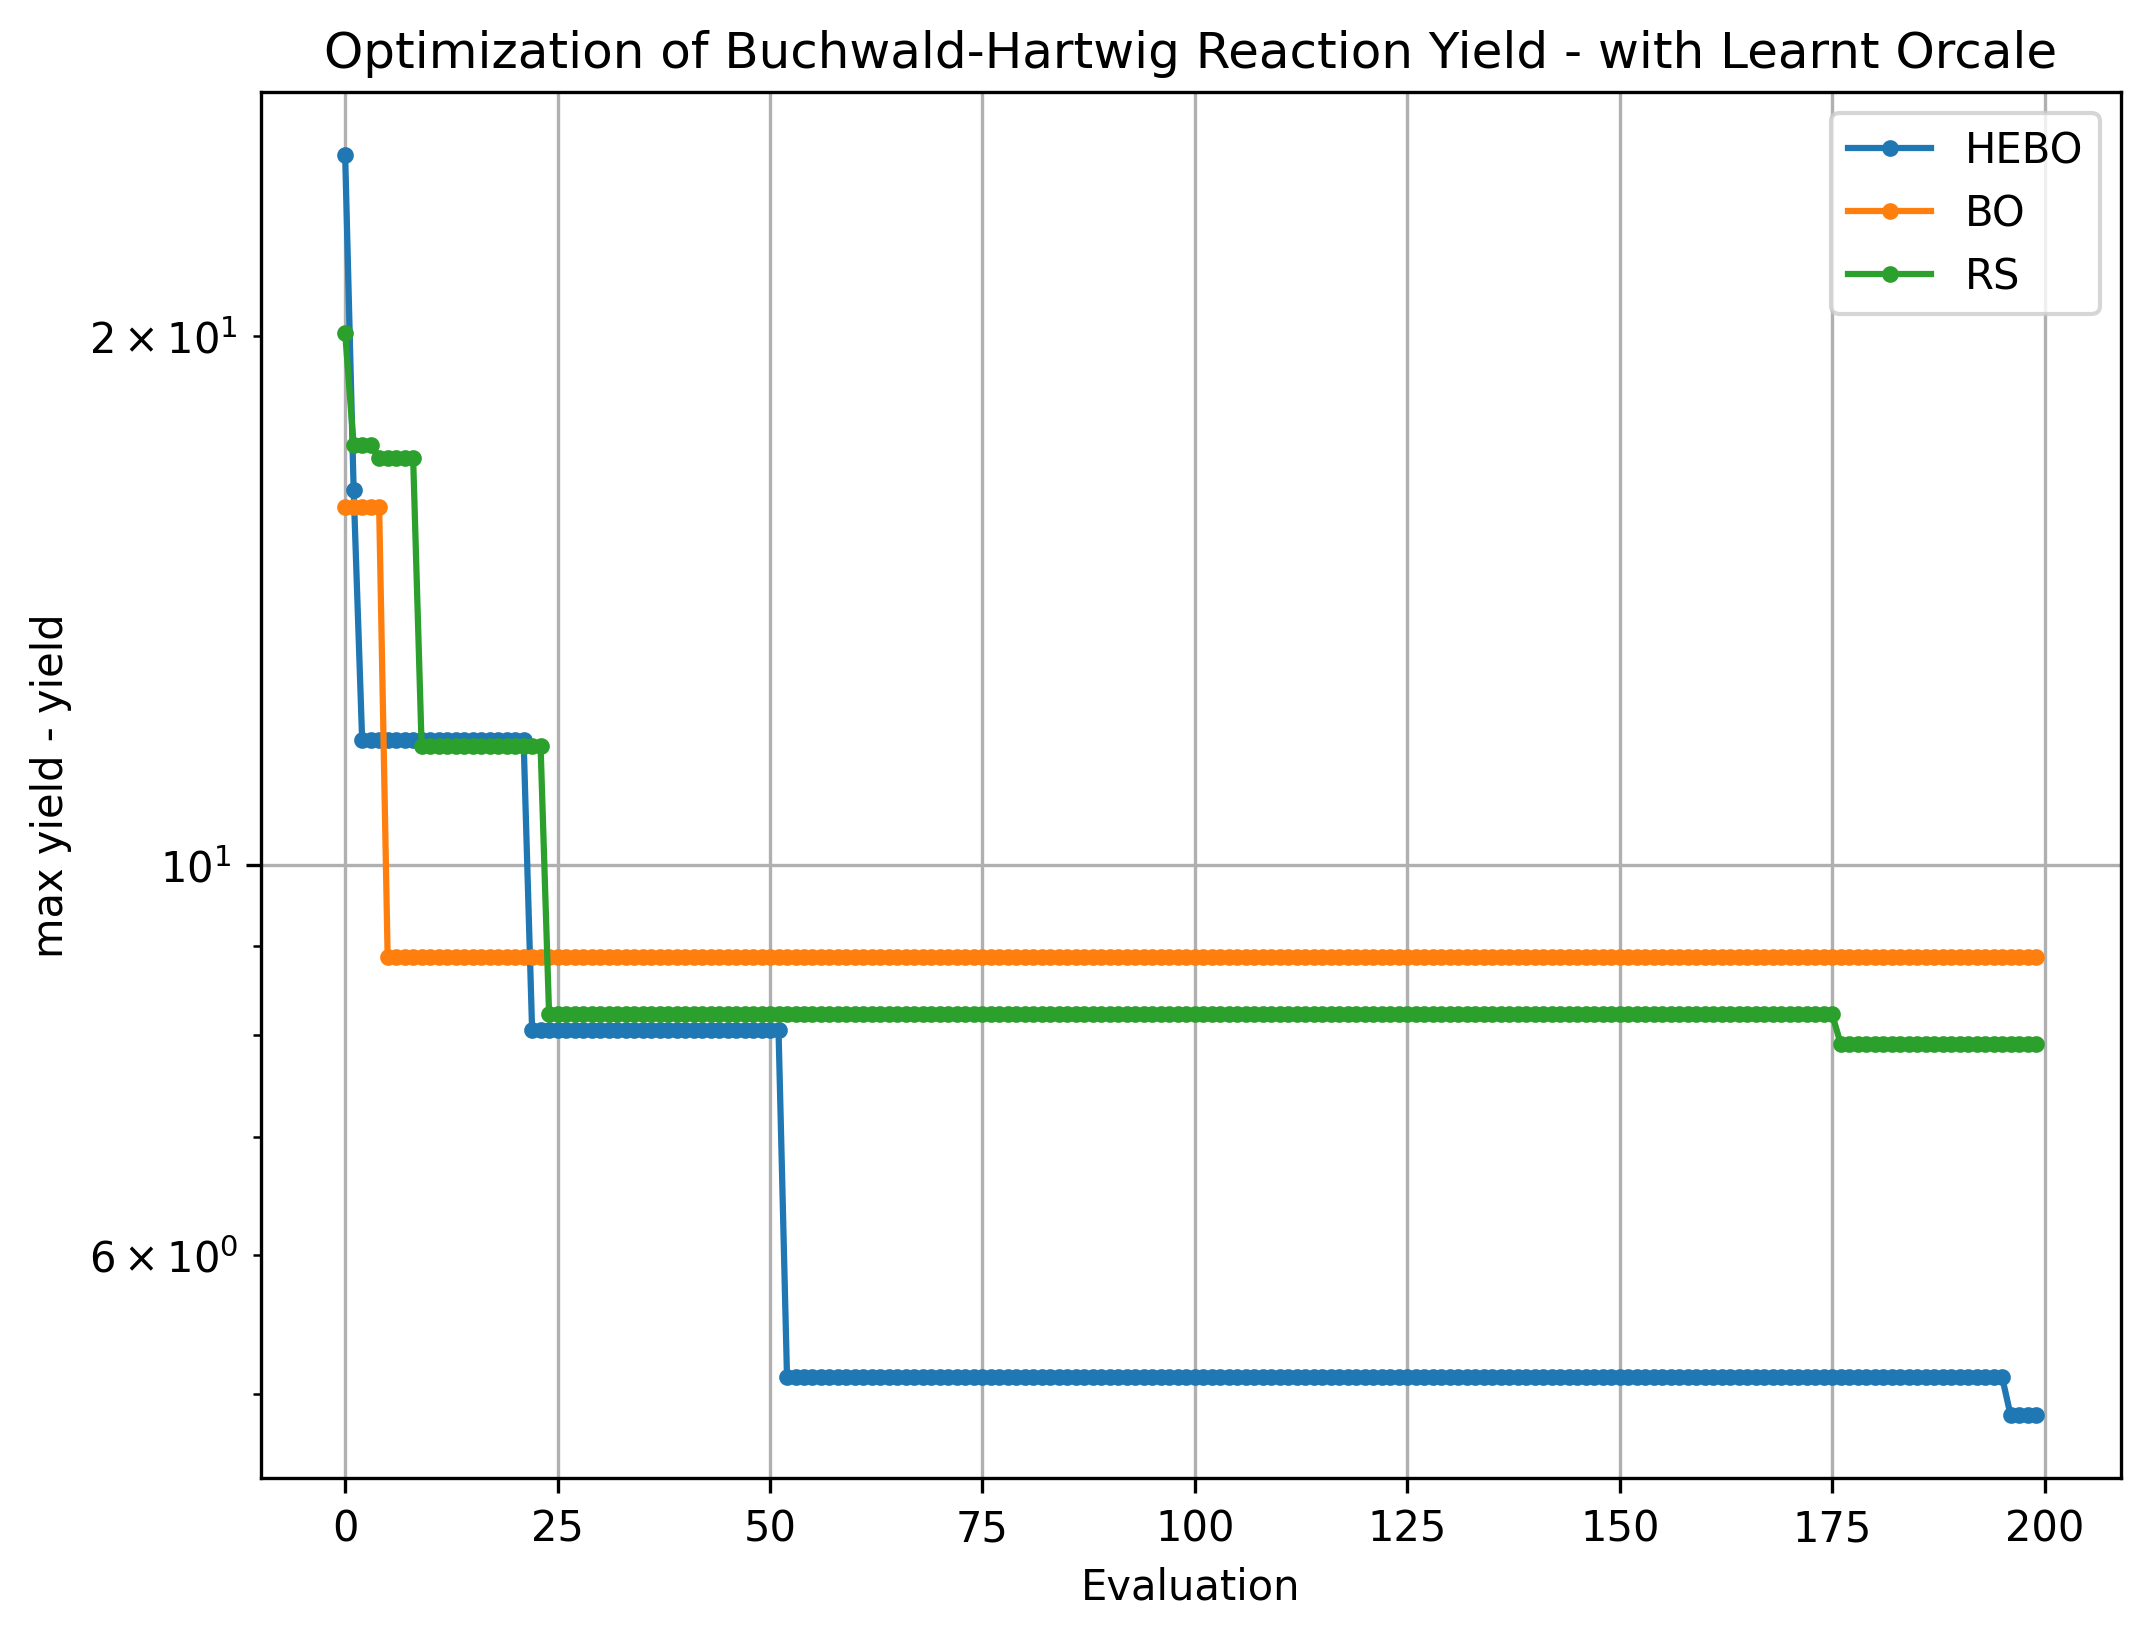

In [77]:
conv_hebo = np.minimum.accumulate(hebo.y)
conv_bo = np.minimum.accumulate(bo.y)
conv_rs = np.minimum.accumulate(rs_log)

plt.figure(figsize = (8,6), dpi=300)
plt.semilogy(conv_hebo[len(X_train):], '.-', label = 'HEBO')
plt.semilogy(conv_bo[len(X_train):], '.-', label = 'BO')
plt.semilogy(conv_rs[len(X_train):], '.-', label = 'RS')
plt.xlabel('Evaluation')
plt.ylabel('max yield - yield')
plt.legend()
plt.grid()
plt.title("Optimization of Buchwald-Hartwig Reaction Yield - with Learnt Orcale")
plt.show()